# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)

# **Data Exploration**

## **Load The Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 33300 Rows and 10 columns with 298 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33300 entries, 0 to 33299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   claim_amount       32638 non-null  str    
 1   policy_age_years   32634 non-null  float64
 2   prev_claims        32635 non-null  float64
 3   injury_severity    32638 non-null  float64
 4   days_to_report     32635 non-null  float64
 5   num_witnesses      32634 non-null  float64
 6   vehicle_age_years  32634 non-null  float64
 7   repair_cost        32633 non-null  float64
 8   agent_flagged      32634 non-null  float64
 9   is_fraud           33300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.8 MB


In [5]:
df.sample(10)

,claim_amount,policy_age_years,prev_claims,injury_severity,days_to_report,num_witnesses,vehicle_age_years,repair_cost,agent_flagged,is_fraud
32216,301721.18,5.7,2.0,4.0,9.0,3.0,2.0,47867.07,0.0,0
11629,285781.87,5.4,0.0,2.0,7.0,1.0,1.0,23323.22,1.0,0
19899,431245.59,4.3,2.0,1.0,41.0,3.0,19.0,42187.14,0.0,1
25835,28975.72,11.9,4.0,3.0,89.0,1.0,0.0,765.14,1.0,0
22619,133635.18,9.2,8.0,1.0,75.0,2.0,14.0,14228.92,0.0,0
23509,182039.04,10.9,1.0,2.0,31.0,4.0,NaN,30412.97,0.0,0
23809,282008.94,2.3,0.0,3.0,35.0,1.0,10.0,10188.46,0.0,0
3526,120402.84,1.9,9.0,1.0,13.0,0.0,2.0,4968.84,0.0,0
13943,19903.11,2.5,1.0,3.0,69.0,0.0,10.0,27695.59,0.0,0
28075,140901.28,NaN,4.0,3.0,52.0,0.0,11.0,29380.28,0.0,0


In [6]:
df.describe()

,policy_age_years,prev_claims,injury_severity,days_to_report,num_witnesses,vehicle_age_years,repair_cost,agent_flagged,is_fraud
count,32634.000000,32635.000000,32638.000000,32635.000000,32634.000000,32634.000000,32633.000000,32634.000000,33300.000000
mean,10.002078,4.483561,2.501838,44.503815,1.986670,9.583716,25276.589015,0.201906,0.501261
std,5.769289,2.877320,1.119884,26.030108,1.511427,5.777644,14292.542373,0.401429,0.500006
min,-2.000000,0.000000,1.000000,-10.000000,0.000000,-5.000000,-1000.000000,0.000000,0.000000
25%,5.000000,2.000000,2.000000,22.000000,1.000000,5.000000,13061.730000,0.000000,0.000000
50%,10.000000,4.000000,3.000000,44.000000,2.000000,10.000000,25225.150000,0.000000,1.000000
75%,15.000000,7.000000,4.000000,67.000000,3.000000,15.000000,37635.840000,0.000000,1.000000
max,20.000000,9.000000,10.000000,89.000000,99.000000,19.000000,49999.330000,1.000000,1.000000


In [7]:
df.isna().sum()

claim_amount         662
policy_age_years     666
prev_claims          665
injury_severity      662
days_to_report       665
num_witnesses        666
vehicle_age_years    666
repair_cost          667
agent_flagged        666
is_fraud               0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created boss')

Copy Created boss


## **DataType**

In [9]:
df_copy['claim_amount'] = df_copy['claim_amount'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [10]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [11]:
Columns = df_copy.columns.tolist()
Columns.remove('agent_flagged')
Columns.remove('is_fraud')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


In [13]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('is_fraud')
Round.remove('injury_severity')
Round.remove('days_to_report')
Round.remove('num_witnesses')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['injury_severity','days_to_report','num_witnesses']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
claim_amount         661
policy_age_years     661
prev_claims          660
injury_severity      661
days_to_report       661
num_witnesses        661
vehicle_age_years    661
repair_cost          661
agent_flagged        660
is_fraud               0
dtype: int64
NaN values in the Dataset After Cleaning is: 
claim_amount         0
policy_age_years     0
prev_claims          0
injury_severity      0
days_to_report       0
num_witnesses        0
vehicle_age_years    0
repair_cost          0
agent_flagged        0
is_fraud             0
dtype: int64


# **Data Preperation**

In [17]:
features = df_copy.columns.tolist()
features.remove('is_fraud')
X = df_copy[features]
y = df_copy['is_fraud']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (33000, 9)
y Shape: (33000,)


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (26400, 9)
X_test Shape:  (6600, 9)
y_train Shape: (26400,)
y_test Shape:  (6600,)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# **Model**

## **Train**

In [36]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.4,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print(f"Best trees used: {model.best_iteration}")
print(f"Model trained ✅")

Best trees used: 11
Model trained ✅


## **Evaluation & Pridict**

In [37]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.74      0.73      0.73      3325
         1.0       0.73      0.73      0.73      3275

    accuracy                           0.73      6600
   macro avg       0.73      0.73      0.73      6600
weighted avg       0.73      0.73      0.73      6600

Accuracy: 0.7327


## **Feature Importance**

In [38]:
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    imp = model.get_booster().get_score(importance_type=imp_type)
    print(f"\n{imp_type.upper()}:")
    for feat, score in sorted(imp.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:25} → {score:.4f}")


WEIGHT:
  f0                        → 185.0000
  f4                        → 147.0000
  f1                        → 127.0000
  f7                        → 125.0000
  f2                        → 113.0000
  f6                        → 102.0000
  f5                        → 60.0000
  f3                        → 42.0000
  f8                        → 34.0000

GAIN:
  f2                        → 50.5409
  f8                        → 49.1613
  f1                        → 13.7747
  f4                        → 11.6928
  f0                        → 11.6708
  f6                        → 9.7439
  f5                        → 9.2899
  f3                        → 8.8204
  f7                        → 5.1500

COVER:
  f8                        → 1198.9651
  f1                        → 838.0009
  f2                        → 830.0363
  f3                        → 659.7354
  f7                        → 626.9333
  f4                        → 597.6019
  f5                        → 593.1669
  f0            

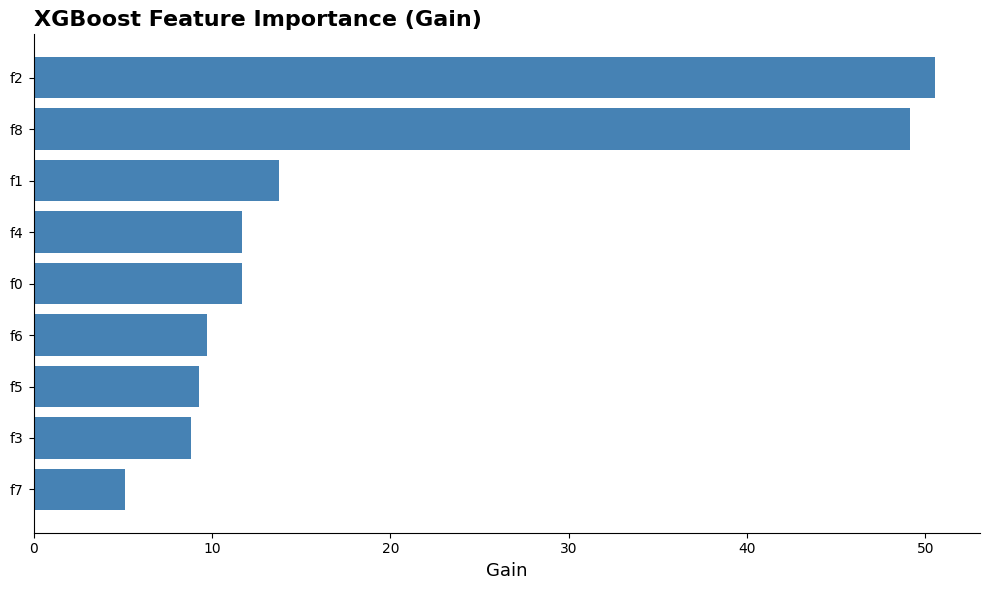

In [39]:
# Plot gain importance
imp_df = pd.DataFrame(
    model.get_booster().get_score(importance_type='gain').items(),
    columns=['Feature', 'Gain']
).sort_values('Gain', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
ax = plt.gca()
ax.invert_yaxis()
ax.spines[['right','top']].set_visible(False)
plt.xlabel('Gain', fontsize=13)
plt.title('XGBoost Feature Importance (Gain)',
          fontweight='bold', fontsize=16, loc='left')
plt.tight_layout()
plt.show()

## **XGBoost Learning Curve**

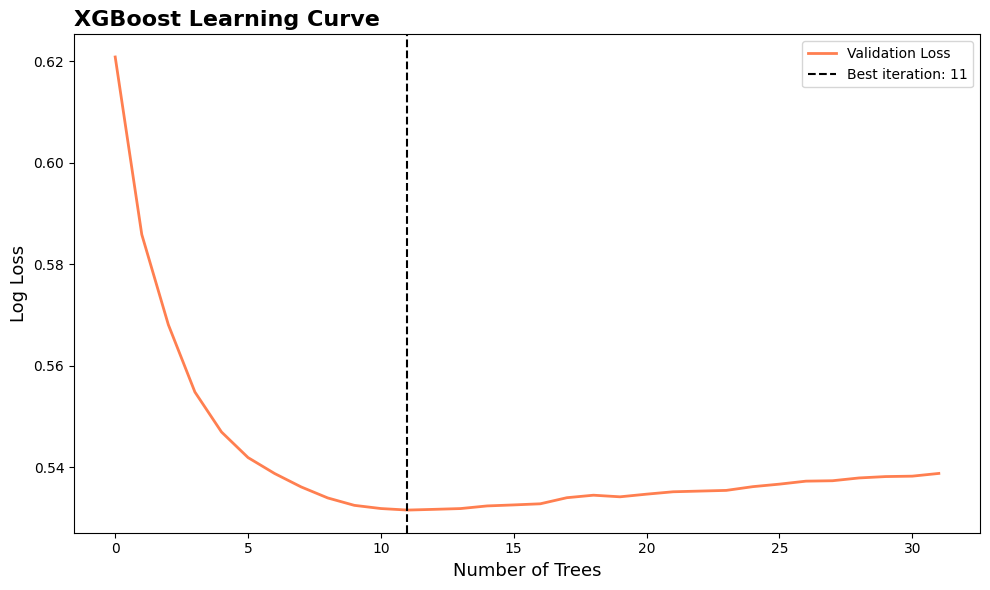

In [40]:
results = model.evals_result()
train_loss = results['validation_0']['logloss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, color='coral', linewidth=2, label='Validation Loss')
plt.axvline(model.best_iteration, linestyle='--', color='black',
            label=f'Best iteration: {model.best_iteration}')
plt.xlabel('Number of Trees', fontsize=13)
plt.ylabel('Log Loss', fontsize=13)
plt.title('XGBoost Learning Curve',
          fontweight='bold', fontsize=16, loc='left')
plt.legend()
plt.tight_layout()
plt.show()

## **Overfitting**

In [41]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"Best iteration:    {model.best_iteration}")

Training Accuracy: 0.7555
Testing Accuracy:  0.7327
Gap:               0.0228
Best iteration:    11


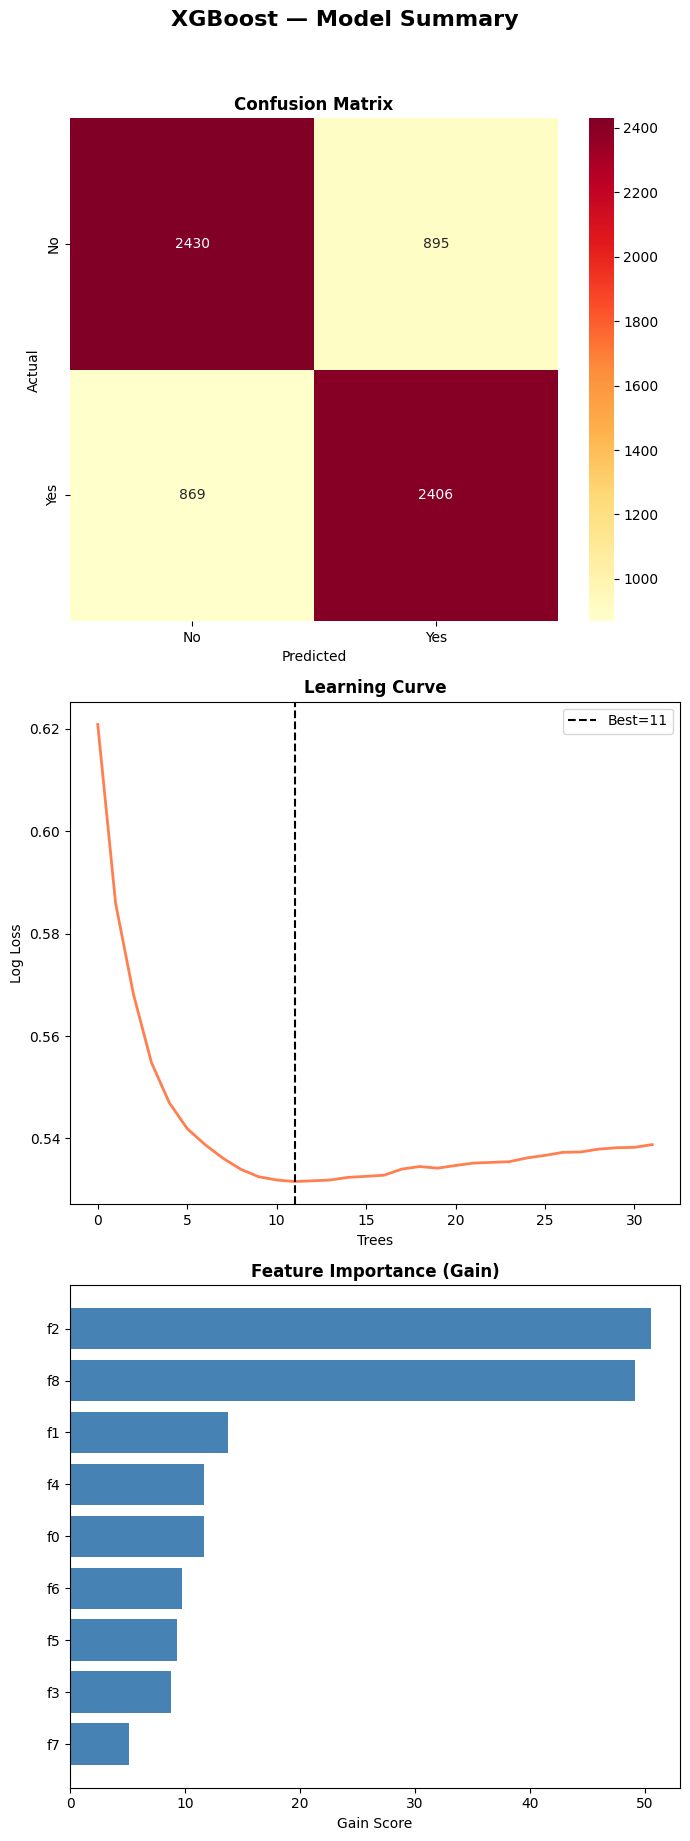

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Learning Curve
results = model.evals_result()
axes[1].plot(results['validation_0']['logloss'],
             color='coral', linewidth=2)
axes[1].axvline(model.best_iteration, linestyle='--',
                color='black', label=f'Best={model.best_iteration}')
axes[1].set_title('Learning Curve', fontweight='bold')
axes[1].set_xlabel('Trees')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

# Plot 3 — Feature Importance (Gain)
imp_df = pd.DataFrame(
    model.get_booster().get_score(importance_type='gain').items(),
    columns=['Feature', 'Gain']
).sort_values('Gain')
axes[2].barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
axes[2].set_title('Feature Importance (Gain)', fontweight='bold')
axes[2].set_xlabel('Gain Score')

plt.suptitle('XGBoost — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()